In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torchaudio
!pip install librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import pickle
import random
import librosa
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [ ]:
with open("/content/drive/MyDrive/final_features.pkl", "rb") as f:
    data = pickle.load(f)

print("Samples:", len(data))

Samples: 3262


In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, 4, batch_first=True)

    def forward(self, q, k, v):
        out, _ = self.attn(q, k, v)
        return out

In [ ]:
class ConformerEncoder(nn.Module):
    def __init__(self, input_dim=80, d_model=128):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)

        self.conformer = torchaudio.models.Conformer(
            input_dim=d_model,
            num_heads=4,
            ffn_dim=256,
            num_layers=2,
            depthwise_conv_kernel_size=3 # Reverting to smaller kernel size to fix CUDA error
        )

    def forward(self, x):
        x = self.input_proj(x)

        lengths = torch.full(
            (x.shape[0],),
            x.shape[1],
            dtype=torch.long,
            device=x.device
        )

        out, _ = self.conformer(x, lengths)
        return out.mean(dim=1)

In [ ]:
class MultiModalModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.audio_encoder = ConformerEncoder()
        self.text_proj = nn.Linear(768, 128)

        self.cross_ta = CrossAttention(128)
        self.cross_at = CrossAttention(128)

        self.fusion = nn.Linear(256, 128)

        self.final = nn.Sequential(
            nn.Linear(128 + 8, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.classifier = nn.Linear(32, 2)

    def forward(self, mel, bert, behavior):

        A = self.audio_encoder(mel).unsqueeze(1)
        T = self.text_proj(bert).unsqueeze(1)

        Z_ta = self.cross_ta(T, A, A)
        Z_at = self.cross_at(A, T, T)

        Z = torch.cat([Z_ta.squeeze(1), Z_at.squeeze(1)], dim=1)
        Z = self.fusion(Z)

        Z_final = torch.cat([Z, behavior], dim=1)

        h = self.final(Z_final)
        logits = self.classifier(h)

        return h, logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalModel().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model_full.pth", map_location=device))
model.eval()

MultiModalModel(
  (audio_encoder): ConformerEncoder(
    (input_proj): Linear(in_features=80, out_features=128, bias=True)
    (conformer): Conformer(
      (conformer_layers): ModuleList(
        (0-1): 2 x ConformerLayer(
          (ffn1): _FeedForwardModule(
            (sequential): Sequential(
              (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (1): Linear(in_features=128, out_features=256, bias=True)
              (2): SiLU()
              (3): Dropout(p=0.0, inplace=False)
              (4): Linear(in_features=256, out_features=128, bias=True)
              (5): Dropout(p=0.0, inplace=False)
            )
          )
          (self_attn_layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (self_attn_dropout): Dropout(p=0.0, inplace=False)
          (conv_module): _

In [ ]:
def extract_mel(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    mel = librosa.power_to_db(mel).T  # (T, 80)

    return mel

In [ ]:
def split_chunks(mel, chunk_size=20, stride=10):
    chunks = []

    for i in range(0, len(mel) - chunk_size, stride):
        chunk = mel[i:i+chunk_size]
        chunks.append(chunk)

    return chunks

In [ ]:
def get_chunk_embeddings(chunks, model, device):

    embeddings = []

    with torch.no_grad():
        for chunk in chunks:
            chunk = torch.tensor(chunk).float().unsqueeze(0).to(device)
            emb = model.audio_encoder(chunk)
            embeddings.append(emb.squeeze(0).cpu())

    return embeddings

In [ ]:
def compute_drift(embeddings):

    drifts = []

    for i in range(len(embeddings) - 1):
        e1 = embeddings[i]
        e2 = embeddings[i+1]

        d = torch.norm(e1 - e2) / (torch.norm(e1) + 1e-6)
        drifts.append(d.item())

    if len(drifts) < 2:
        return None, []

    return np.mean(drifts), drifts

In [ ]:
def compute_consistency(drifts, pause, rate):

    drift_std = np.std(drifts)
    pause_std = np.std([pause])
    rate_std = np.std([rate])

    # ✅ stable version
    consistency = np.exp(-(drift_std + pause_std + rate_std))

    return consistency

In [ ]:
drift_scores = []
consistency_scores = []

for item in data:

    mel = extract_mel(item["audio"])

    pause = item["features"]["pause_count"]
    rate = item["features"]["speech_rate"]

    chunks = split_chunks(mel)

    embeddings = get_chunk_embeddings(chunks, model, device)

    drift_score, drift_list = compute_drift(embeddings)

    if drift_score is None:
        continue

    consistency = compute_consistency(drift_list, pause, rate)

    drift_scores.append(drift_score)
    consistency_scores.append(consistency)

    item["drift"] = drift_score
    item["consistency"] = consistency

print("✅ Done")

✅ Done


Total samples: 3262
Samples with drift: 3148


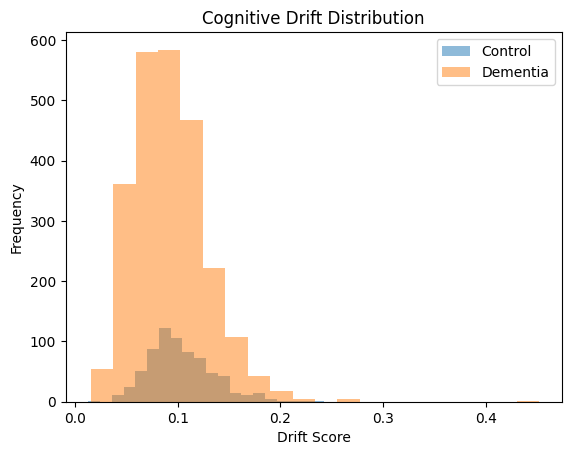

In [ ]:
# ✅ safest way (no KeyError possible)
dementia = [d.get("drift") for d in data if d.get("drift") is not None and d["label"] == 1]
control  = [d.get("drift") for d in data if d.get("drift") is not None and d["label"] == 0]

# ✅ debug check
print("Total samples:", len(data))
print("Samples with drift:", len(dementia) + len(control))

# ✅ plot
import matplotlib.pyplot as plt

plt.hist(control, bins=20, alpha=0.5, label="Control")
plt.hist(dementia, bins=20, alpha=0.5, label="Dementia")

plt.legend()
plt.title("Cognitive Drift Distribution")
plt.xlabel("Drift Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(control, dementia)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: 7.08960651700787
P-value: 1.653424463113374e-12


In [ ]:
print("Control mean:", np.mean(control))
print("Dementia mean:", np.mean(dementia))

Control mean: 0.10314216788900689
Dementia mean: 0.09255345325814707


Total samples: 3262
Samples with consistency: 3148


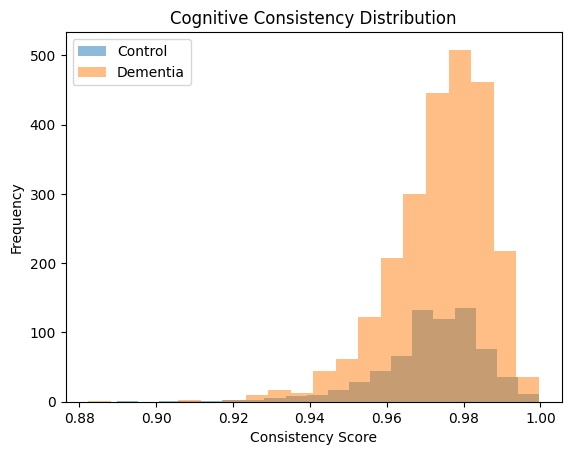

In [ ]:
# ✅ safe extraction (no crash)
dementia_c = [d.get("consistency") for d in data if d.get("consistency") is not None and d["label"] == 1]
control_c  = [d.get("consistency") for d in data if d.get("consistency") is not None and d["label"] == 0]

# ✅ debug check
print("Total samples:", len(data))
print("Samples with consistency:", len(dementia_c) + len(control_c))

# ✅ plot
import matplotlib.pyplot as plt

plt.hist(control_c, bins=20, alpha=0.5, label="Control")
plt.hist(dementia_c, bins=20, alpha=0.5, label="Dementia")

plt.legend()
plt.title("Cognitive Consistency Distribution")
plt.xlabel("Consistency Score")
plt.ylabel("Frequency")
plt.show()

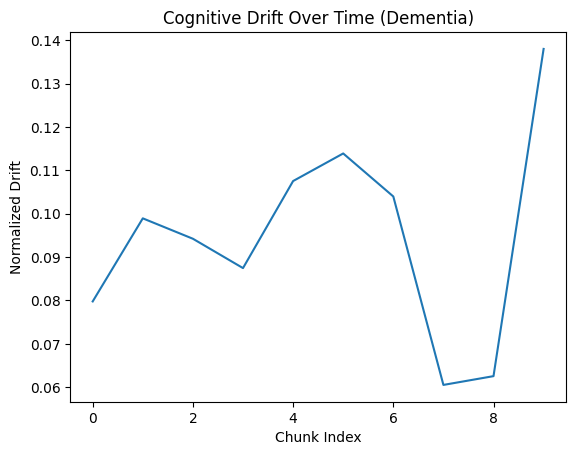

In [ ]:
for item in data:
    if item["label"] == 1:

        mel = extract_mel(item["audio"])
        chunks = split_chunks(mel)
        embeddings = get_chunk_embeddings(chunks, model, device)
        _, drift_list = compute_drift(embeddings)

        if len(drift_list) > 5:
            break

plt.plot(drift_list)
plt.title("Cognitive Drift Over Time (Dementia)")
plt.xlabel("Chunk Index")
plt.ylabel("Normalized Drift")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


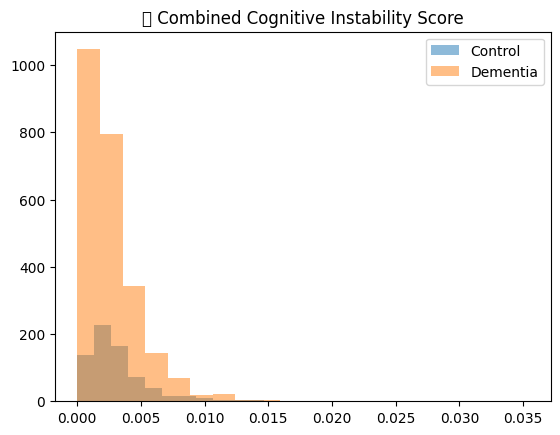

In [ ]:
dementia_comb = [
    d["drift"] * (1 - d["consistency"])
    for d in data if d.get("drift") is not None and d.get("consistency") is not None and d["label"] == 1
]

control_comb = [
    d["drift"] * (1 - d["consistency"])
    for d in data if d.get("drift") is not None and d.get("consistency") is not None and d["label"] == 0
]

plt.hist(control_comb, bins=20, alpha=0.5, label="Control")
plt.hist(dementia_comb, bins=20, alpha=0.5, label="Dementia")

plt.legend()
plt.title("🔥 Combined Cognitive Instability Score")
plt.show()

In [ ]:
print("Drift p-value:", ttest_ind(control, dementia).pvalue)
print("Consistency p-value:", ttest_ind(control_c, dementia_c).pvalue)
print("Combined p-value:", ttest_ind(control_comb, dementia_comb).pvalue)

Drift p-value: 1.653424463113374e-12
Consistency p-value: 4.3612880389392636e-05
Combined p-value: 1.632108630663648e-06


COGNITIVE BREAKDOWN — FULL CLEAN CODE

In [ ]:
import numpy as np
import torch
import librosa

In [ ]:
 def extract_mel(audio_path):
    y, sr = librosa.load(audio_path, sr=16000)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    return librosa.power_to_db(mel).T

In [ ]:
 def split_chunks(mel, chunk_size=20, stride=10):
    chunks = []
    for i in range(0, len(mel) - chunk_size, stride):
        chunks.append(mel[i:i+chunk_size])
    return chunks

In [ ]:
def get_chunk_embeddings(chunks, model, device):

    embeddings = []

    with torch.no_grad():
        for chunk in chunks:
            chunk = torch.tensor(chunk).float().unsqueeze(0).to(device)
            emb = model.audio_encoder(chunk)
            embeddings.append(emb.squeeze(0).cpu())

    return embeddings

In [ ]:
def compute_drift_list(embeddings):

    drifts = []

    for i in range(len(embeddings) - 1):
        e1, e2 = embeddings[i], embeddings[i+1]
        d = torch.norm(e1 - e2) / (torch.norm(e1) + 1e-6)
        drifts.append(d.item())

    return drifts

In [ ]:
def compute_breakdown(drift_list):

    if len(drift_list) < 3:
        return 0.0, [], 0.0

    drift_arr = np.array(drift_list)

    # adaptive threshold
    threshold = drift_arr.mean() + drift_arr.std()

    # breakdown points
    break_points = [i for i, d in enumerate(drift_arr) if d > threshold]

    # normalized score
    breakdown_score = len(break_points) / len(drift_arr)

    return breakdown_score, break_points, threshold

In [ ]:
breakdown_scores = []

for item in data:

    mel = extract_mel(item["audio"])

    chunks = split_chunks(mel)

    embeddings = get_chunk_embeddings(chunks, model, device)

    drift_list = compute_drift_list(embeddings)

    # compute breakdown
    breakdown_score, break_points, threshold = compute_breakdown(drift_list)

    item["breakdown"] = breakdown_score

    breakdown_scores.append(breakdown_score)

print("✅ Breakdown computed")

✅ Breakdown computed


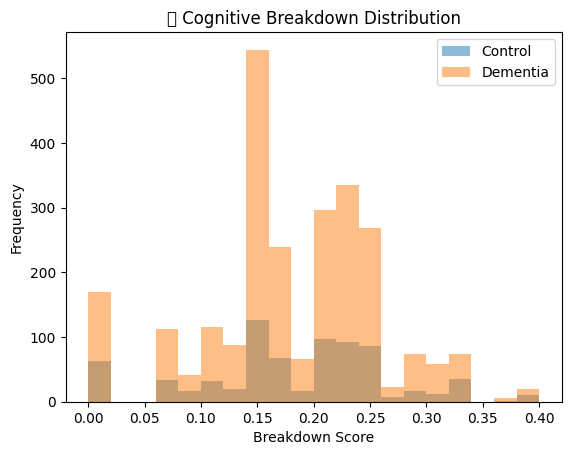

In [ ]:
import matplotlib.pyplot as plt

dementia_b = [d["breakdown"] for d in data if d["label"] == 1]
control_b  = [d["breakdown"] for d in data if d["label"] == 0]

plt.hist(control_b, bins=20, alpha=0.5, label="Control")
plt.hist(dementia_b, bins=20, alpha=0.5, label="Dementia")

plt.legend()
plt.title("🔥 Cognitive Breakdown Distribution")
plt.xlabel("Breakdown Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# pick one dementia sample
for item in data:
    if item["label"] == 1:

        mel = extract_mel(item["audio"])
        chunks = split_chunks(mel)
        embeddings = get_chunk_embeddings(chunks, model, device)
        drift_list = compute_drift_list(embeddings)

        breakdown_score, break_points, threshold = compute_breakdown(drift_list)

        if len(drift_list) > 5:
            break

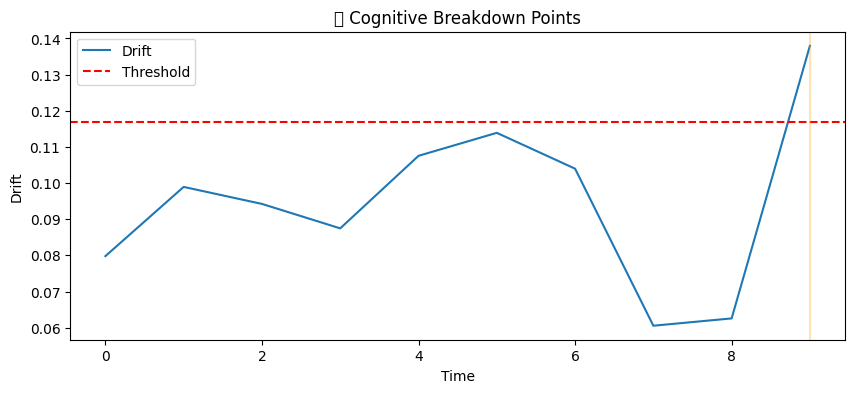

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(drift_list, label="Drift")
plt.axhline(threshold, color='red', linestyle='--', label="Threshold")

for bp in break_points:
    plt.axvline(bp, color='orange', alpha=0.3)

plt.legend()
plt.title("🔥 Cognitive Breakdown Points")
plt.xlabel("Time")
plt.ylabel("Drift")
plt.show()

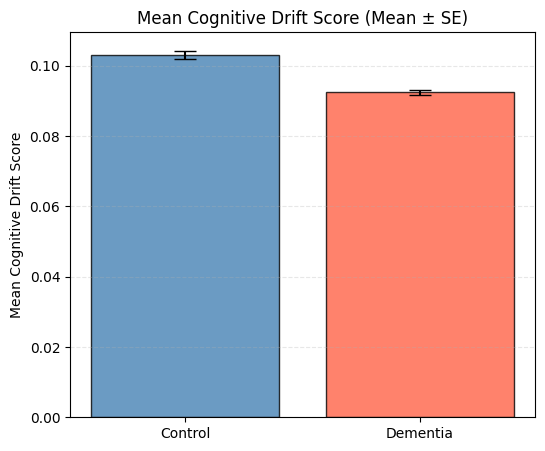

Control
Mean = 0.1031
SD   = 0.0322
SE   = 0.0012

Dementia
Mean = 0.0926
SD   = 0.0355
SE   = 0.0007


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract drift scores
control = [
    d["drift"] for d in data
    if d.get("drift") is not None and d["label"] == 0
]

dementia = [
    d["drift"] for d in data
    if d.get("drift") is not None and d["label"] == 1
]

# Mean
control_mean = np.mean(control)
dementia_mean = np.mean(dementia)

# Standard Deviation
control_sd = np.std(control, ddof=1)
dementia_sd = np.std(dementia, ddof=1)

# Standard Error
control_se = control_sd / np.sqrt(len(control))
dementia_se = dementia_sd / np.sqrt(len(dementia))

# Plot
plt.figure(figsize=(6,5))

plt.bar(
    ["Control", "Dementia"],
    [control_mean, dementia_mean],
    yerr=[control_se, dementia_se],
    capsize=8,
    color=["steelblue", "tomato"],
    edgecolor="black",
    alpha=0.8
)

plt.ylabel("Mean Cognitive Drift Score")
plt.title("Mean Cognitive Drift Score (Mean ± SE)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

# Print statistics
print("Control")
print(f"Mean = {control_mean:.4f}")
print(f"SD   = {control_sd:.4f}")
print(f"SE   = {control_se:.4f}")

print("\nDementia")
print(f"Mean = {dementia_mean:.4f}")
print(f"SD   = {dementia_sd:.4f}")
print(f"SE   = {dementia_se:.4f}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []

for d in data:

    if (
        d.get("drift") is None or
        d.get("consistency") is None or
        d.get("breakdown") is None
    ):
        continue

    rows.append({

        "Pause Count":
            d["features"]["pause_count"],

        "Speech Rate":
            d["features"]["speech_rate"],

        "Cognitive Drift":
            d["drift"],

        "Consistency":
            d["consistency"],

        "Breakdown":
            d["breakdown"],

        "Label":
            d["label"]

    })

feature_df = pd.DataFrame(rows)

plt.figure(figsize=(8,6))

sns.heatmap(

    feature_df.drop(columns=["Label"]).corr(),

    annot=True,

    cmap="coolwarm",

    linewidths=0.5,

    fmt=".2f"

)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
import pandas as pd

rows = []

for d in data:

    if (
        d.get("drift") is not None and
        d.get("consistency") is not None and
        d.get("breakdown") is not None
    ):

        rows.append({
            "Pause": d["features"]["pause_count"],
            "Speech Rate": d["features"]["speech_rate"],
            "Drift": d["drift"],
            "Consistency": d["consistency"],
            "Breakdown": d["breakdown"],
            "Label": d["label"]
        })

feature_df = pd.DataFrame(rows)

print(feature_df.shape)
print(feature_df.head())

NameError: name 'data' is not defined

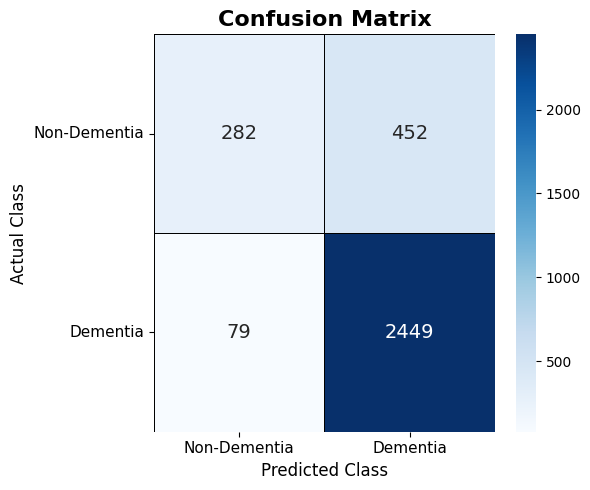

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix values
cm = np.array([
    [282, 452],
    [79, 2449]
])

# Class labels
labels = ["Non-Dementia", "Dementia"]

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    annot_kws={"size": 14}
)

plt.title("Confusion Matrix", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

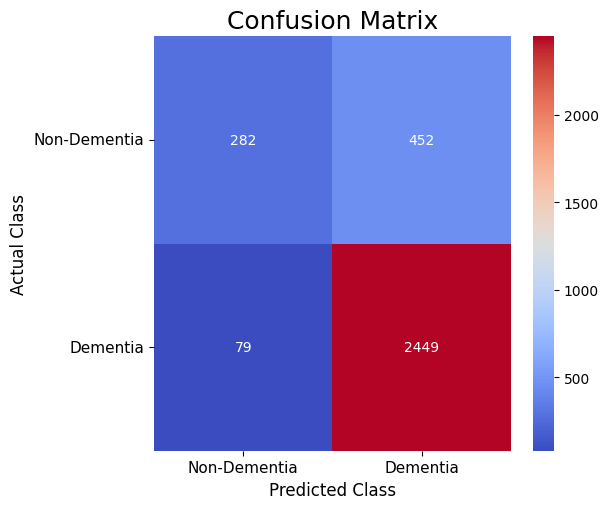

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([
    [282, 452],
    [79, 2449]
])

labels = ["Non-Dementia", "Dementia"]

plt.figure(figsize=(6.2, 5.2))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",          # Use "Blues" if you prefer the blue theme
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0,
    cbar=True
)

plt.title("Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()